# Проект предсказания риска сердечных приступов

Требуется разработать модель машинного обучения. Доступен обучающий датасет и тестовый датасет, не содержащий правильных ответов. 

Задачи проекта
- Исследование датасета (предполагается поиск дополнительной информации для лучшего понимания природы данных)
- Предобработка данных. Некоторые колонки потребуется преобразовать к нужному типу данных.
- Обучение модели
- Подготовка предсказания на тестовой выборке. Файл предсказаний должен быть в csv формате и содержать 2 столбца: “id” и “prediction”.

## 1. Импорт и первичный анализ датасетов

In [31]:
!pip install shap==0.49.1 -q
!pip install -U scikit-learn==1.5.1 -q
!pip install phik -q

In [32]:
# Импорт библиотек
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import re
import sklearn
import joblib
import warnings

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, f1_score
from scipy.stats import randint

from phik.report import plot_correlation_matrix
from phik import report

In [33]:
warnings.filterwarnings('ignore', category=FutureWarning) 

In [34]:
print(f"scikit-learn версия: {sklearn.__version__}")

scikit-learn версия: 1.5.1


In [35]:
# Константы
RANDOM_STATE = 42
TEST_SIZE = 0.20

In [36]:
# Импорт heart_train и просмотр общей информации
df_train = pd.read_csv('./datasets/heart_train.csv')
df_train.info()
df_train.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8685 entries, 0 to 8684
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Unnamed: 0                       8685 non-null   int64  
 1   Age                              8685 non-null   float64
 2   Cholesterol                      8685 non-null   float64
 3   Heart rate                       8685 non-null   float64
 4   Diabetes                         8442 non-null   float64
 5   Family History                   8442 non-null   float64
 6   Smoking                          8442 non-null   float64
 7   Obesity                          8442 non-null   float64
 8   Alcohol Consumption              8442 non-null   float64
 9   Exercise Hours Per Week          8685 non-null   float64
 10  Diet                             8685 non-null   int64  
 11  Previous Heart Problems          8442 non-null   float64
 12  Medication Use      

,Unnamed: 0,Age,Cholesterol,Heart rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,...,Physical Activity Days Per Week,Sleep Hours Per Day,Heart Attack Risk (Binary),Blood sugar,CK-MB,Troponin,Gender,Systolic blood pressure,Diastolic blood pressure,id
0,0,0.359551,0.732143,0.074244,1.0,1.0,1.0,1.0,1.0,0.535505,...,3.0,0.333333,0.0,0.227018,0.048229,0.036512,Male,0.212903,0.709302,2664
1,1,0.202247,0.325000,0.047663,1.0,1.0,0.0,0.0,1.0,0.068690,...,3.0,0.833333,0.0,0.150198,0.017616,0.000194,Female,0.412903,0.569767,9287
2,2,0.606742,0.860714,0.055912,1.0,0.0,1.0,1.0,1.0,0.944001,...,2.0,1.000000,0.0,0.227018,0.048229,0.036512,Female,0.238710,0.220930,5379
3,3,0.730337,0.007143,0.053162,0.0,0.0,1.0,0.0,1.0,0.697023,...,0.0,0.333333,1.0,0.227018,0.048229,0.036512,Female,0.348387,0.267442,8222
4,4,0.775281,0.757143,0.021998,0.0,0.0,1.0,0.0,1.0,0.412878,...,5.0,1.000000,1.0,0.227018,0.048229,0.036512,Male,0.619355,0.441860,4047


In [37]:
# Импорт heart_test и просмотр общей информации
df_test = pd.read_csv('./datasets/heart_test.csv')
df_test.info()
df_test.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 966 entries, 0 to 965
Data columns (total 27 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Unnamed: 0                       966 non-null    int64  
 1   Age                              966 non-null    float64
 2   Cholesterol                      966 non-null    float64
 3   Heart rate                       966 non-null    float64
 4   Diabetes                         935 non-null    float64
 5   Family History                   935 non-null    float64
 6   Smoking                          935 non-null    float64
 7   Obesity                          935 non-null    float64
 8   Alcohol Consumption              935 non-null    float64
 9   Exercise Hours Per Week          966 non-null    float64
 10  Diet                             966 non-null    int64  
 11  Previous Heart Problems          935 non-null    float64
 12  Medication Use        

,Unnamed: 0,Age,Cholesterol,Heart rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,...,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Blood sugar,CK-MB,Troponin,Gender,Systolic blood pressure,Diastolic blood pressure,id
0,0,0.494382,0.264286,0.062328,0.0,1.0,1.0,1.0,1.0,0.361618,...,0.306494,1.0,0.333333,0.227018,0.048229,0.036512,Male,0.283871,0.372093,7746
1,1,0.224719,0.953571,0.082493,1.0,0.0,0.0,1.0,0.0,0.996483,...,0.087013,0.0,0.166667,0.227018,0.048229,0.036512,Female,0.703226,0.441860,4202
2,2,0.629213,0.092857,0.064161,0.0,1.0,1.0,1.0,0.0,0.995561,...,0.205195,7.0,1.000000,0.102767,0.002666,0.088455,Male,0.458065,0.779070,6632
3,3,0.460674,0.567857,0.055912,1.0,1.0,1.0,1.0,1.0,0.437277,...,0.163636,0.0,0.666667,0.203557,0.056390,0.271774,Female,0.741935,0.255814,4639
4,4,0.719101,0.485714,0.022915,1.0,0.0,1.0,0.0,1.0,0.514920,...,0.580519,5.0,0.000000,0.227018,0.048229,0.036512,Male,0.412903,0.395349,4825


### Вывод
1. Переименовать колонки heart_test.csv и heart_train исключив пробелы, привести прописные символы наименования к строчным
2. Удалить столбец неизвестных значений Unnamed: 0
3. По значениям видно что признаки отмасштабированы (в т.ч. с целью быть обезличенными)

## 2. Предобработка данных

In [38]:
# Название колонок к snake_case
def to_snake_case(df):
    df.columns = [
    re.sub(r'[^a-z0-9_]', '',
           column_name.replace(' ', '_')
           .lower()
    )
    for column_name in df.columns
    ]
    return df

In [39]:
to_snake_case(df_train)
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8685 entries, 0 to 8684
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   unnamed_0                        8685 non-null   int64  
 1   age                              8685 non-null   float64
 2   cholesterol                      8685 non-null   float64
 3   heart_rate                       8685 non-null   float64
 4   diabetes                         8442 non-null   float64
 5   family_history                   8442 non-null   float64
 6   smoking                          8442 non-null   float64
 7   obesity                          8442 non-null   float64
 8   alcohol_consumption              8442 non-null   float64
 9   exercise_hours_per_week          8685 non-null   float64
 10  diet                             8685 non-null   int64  
 11  previous_heart_problems          8442 non-null   float64
 12  medication_use      

In [40]:
to_snake_case(df_test)
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 966 entries, 0 to 965
Data columns (total 27 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   unnamed_0                        966 non-null    int64  
 1   age                              966 non-null    float64
 2   cholesterol                      966 non-null    float64
 3   heart_rate                       966 non-null    float64
 4   diabetes                         935 non-null    float64
 5   family_history                   935 non-null    float64
 6   smoking                          935 non-null    float64
 7   obesity                          935 non-null    float64
 8   alcohol_consumption              935 non-null    float64
 9   exercise_hours_per_week          966 non-null    float64
 10  diet                             966 non-null    int64  
 11  previous_heart_problems          935 non-null    float64
 12  medication_use        

Приведены наименования колонок датафреймов к snake_case

In [41]:
df_train = df_train.drop(columns=['unnamed_0'])
df_test = df_test.drop(columns=['unnamed_0'])

print('df_test:', df_test.columns)
print('df_train:', df_train.columns)

df_test: Index(['age', 'cholesterol', 'heart_rate', 'diabetes', 'family_history',
       'smoking', 'obesity', 'alcohol_consumption', 'exercise_hours_per_week',
       'diet', 'previous_heart_problems', 'medication_use', 'stress_level',
       'sedentary_hours_per_day', 'income', 'bmi', 'triglycerides',
       'physical_activity_days_per_week', 'sleep_hours_per_day', 'blood_sugar',
       'ckmb', 'troponin', 'gender', 'systolic_blood_pressure',
       'diastolic_blood_pressure', 'id'],
      dtype='object')
df_train: Index(['age', 'cholesterol', 'heart_rate', 'diabetes', 'family_history',
       'smoking', 'obesity', 'alcohol_consumption', 'exercise_hours_per_week',
       'diet', 'previous_heart_problems', 'medication_use', 'stress_level',
       'sedentary_hours_per_day', 'income', 'bmi', 'triglycerides',
       'physical_activity_days_per_week', 'sleep_hours_per_day',
       'heart_attack_risk_binary', 'blood_sugar', 'ckmb', 'troponin', 'gender',
       'systolic_blood_pressure', 'd

Удалены лишние колонки датасетов

In [42]:
#Анализ пропусков
df_train.isna().sum()

age                                  0
cholesterol                          0
heart_rate                           0
diabetes                           243
family_history                     243
smoking                            243
obesity                            243
alcohol_consumption                243
exercise_hours_per_week              0
diet                                 0
previous_heart_problems            243
medication_use                     243
stress_level                       243
sedentary_hours_per_day              0
income                               0
bmi                                  0
triglycerides                        0
physical_activity_days_per_week    243
sleep_hours_per_day                  0
heart_attack_risk_binary             0
blood_sugar                          0
ckmb                                 0
troponin                             0
gender                               0
systolic_blood_pressure              0
diastolic_blood_pressure 

In [43]:
df_train[df_train.isna().any(axis=1)]

,age,cholesterol,heart_rate,diabetes,family_history,smoking,obesity,alcohol_consumption,exercise_hours_per_week,diet,...,physical_activity_days_per_week,sleep_hours_per_day,heart_attack_risk_binary,blood_sugar,ckmb,troponin,gender,systolic_blood_pressure,diastolic_blood_pressure,id
16,0.449438,0.49978,0.063245,NaN,NaN,NaN,NaN,NaN,0.50211,3,...,NaN,0.504621,0.0,0.233202,0.026692,0.000777,1.0,0.393548,0.255814,9528
90,0.370787,0.49978,0.066911,NaN,NaN,NaN,NaN,NaN,0.50211,3,...,NaN,0.504621,0.0,0.154150,0.004702,0.042043,1.0,0.258065,0.337209,9640
92,0.629213,0.49978,0.073327,NaN,NaN,NaN,NaN,NaN,0.50211,3,...,NaN,0.504621,0.0,0.256917,0.012310,0.000777,0.0,0.258065,0.232558,9515
185,0.516854,0.49978,0.045830,NaN,NaN,NaN,NaN,NaN,0.50211,3,...,NaN,0.504621,0.0,0.559289,0.006704,0.000291,0.0,0.174194,0.151163,9491
188,0.269663,0.49978,0.035747,NaN,NaN,NaN,NaN,NaN,0.50211,3,...,NaN,0.504621,0.0,0.112648,0.051218,0.000485,0.0,0.225806,0.162791,9448
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8461,0.719101,0.49978,0.049496,NaN,NaN,NaN,NaN,NaN,0.50211,3,...,NaN,0.504621,0.0,0.138340,0.004034,0.003204,1.0,0.548387,0.558140,9455
8509,0.651685,0.49978,0.036664,NaN,NaN,NaN,NaN,NaN,0.50211,3,...,NaN,0.504621,0.0,0.239130,0.055790,0.060783,1.0,0.729032,0.779070,9506
8536,0.651685,0.49978,0.054079,NaN,NaN,NaN,NaN,NaN,0.50211,3,...,NaN,0.504621,0.0,0.276680,0.008673,0.150403,1.0,0.606452,0.790698,9474
8619,0.606742,0.49978,0.059578,NaN,NaN,NaN,NaN,NaN,0.50211,3,...,NaN,0.504621,0.0,0.156126,0.057692,0.000583,0.0,0.387097,0.500000,9467


Приимущественно пропуски повторяются в одинаковых строках - удалим 243 строки из датасета в 8685 это не должно сказаться на обучении модели


In [44]:
df_train.dropna(inplace=True)

#Повторный анализ пропусков
df_train.isna().sum()

age                                0
cholesterol                        0
heart_rate                         0
diabetes                           0
family_history                     0
smoking                            0
obesity                            0
alcohol_consumption                0
exercise_hours_per_week            0
diet                               0
previous_heart_problems            0
medication_use                     0
stress_level                       0
sedentary_hours_per_day            0
income                             0
bmi                                0
triglycerides                      0
physical_activity_days_per_week    0
sleep_hours_per_day                0
heart_attack_risk_binary           0
blood_sugar                        0
ckmb                               0
troponin                           0
gender                             0
systolic_blood_pressure            0
diastolic_blood_pressure           0
id                                 0
d

In [45]:
#Анализ пропусков df_test
df_test.isna().sum()

age                                 0
cholesterol                         0
heart_rate                          0
diabetes                           31
family_history                     31
smoking                            31
obesity                            31
alcohol_consumption                31
exercise_hours_per_week             0
diet                                0
previous_heart_problems            31
medication_use                     31
stress_level                       31
sedentary_hours_per_day             0
income                              0
bmi                                 0
triglycerides                       0
physical_activity_days_per_week    31
sleep_hours_per_day                 0
blood_sugar                         0
ckmb                                0
troponin                            0
gender                              0
systolic_blood_pressure             0
diastolic_blood_pressure            0
id                                  0
dtype: int64

In [46]:
df_test[df_test.isna().any(axis=1)].sample(10)

,age,cholesterol,heart_rate,diabetes,family_history,smoking,obesity,alcohol_consumption,exercise_hours_per_week,diet,...,triglycerides,physical_activity_days_per_week,sleep_hours_per_day,blood_sugar,ckmb,troponin,gender,systolic_blood_pressure,diastolic_blood_pressure,id
563,0.516854,0.49978,0.084326,NaN,NaN,NaN,NaN,NaN,0.50211,3,...,0.503603,NaN,0.504621,0.102767,0.017048,0.001165,1.0,0.322581,0.313953,9457
456,0.348315,0.49978,1.000000,NaN,NaN,NaN,NaN,NaN,0.50211,3,...,0.503603,NaN,0.504621,0.146245,0.003367,0.097971,1.0,0.490323,0.616279,9394
60,0.370787,0.49978,0.056829,NaN,NaN,NaN,NaN,NaN,0.50211,3,...,0.503603,NaN,0.504621,0.199605,0.005970,0.006408,1.0,0.387097,0.220930,9391
920,0.651685,0.49978,0.057745,NaN,NaN,NaN,NaN,NaN,0.50211,3,...,0.503603,NaN,0.504621,0.490119,0.006003,0.002427,0.0,0.374194,0.290698,9521
475,0.280899,0.49978,0.037580,NaN,NaN,NaN,NaN,NaN,0.50211,3,...,0.503603,NaN,0.504621,0.217391,0.004268,0.000388,0.0,0.012903,0.441860,9644
423,0.584270,0.49978,0.043996,NaN,NaN,NaN,NaN,NaN,0.50211,3,...,0.503603,NaN,0.504621,0.150198,0.006337,0.001359,1.0,0.167742,0.220930,9447
156,0.516854,0.49978,0.045830,NaN,NaN,NaN,NaN,NaN,0.50211,3,...,0.503603,NaN,0.504621,0.219368,1.000000,0.000583,1.0,0.335484,0.220930,9490
651,0.348315,0.49978,0.076077,NaN,NaN,NaN,NaN,NaN,0.50211,3,...,0.503603,NaN,0.504621,0.154150,0.008072,0.006311,1.0,0.322581,0.500000,9636
634,0.303371,0.49978,0.080660,NaN,NaN,NaN,NaN,NaN,0.50211,3,...,0.503603,NaN,0.504621,0.138340,0.011809,0.000388,1.0,0.225806,0.337209,9461
602,0.629213,0.49978,0.069661,NaN,NaN,NaN,NaN,NaN,0.50211,3,...,0.503603,NaN,0.504621,0.247036,0.003901,0.002913,0.0,0.529032,0.488372,9543


Пропуски повторяются в одинаковых строках - удалим 31 строку из датасета в 966 это не должно сказаться на обучении модели


In [47]:
df_test.dropna(inplace=True)

#Повторный анализ пропусков
df_test.isna().sum()

age                                0
cholesterol                        0
heart_rate                         0
diabetes                           0
family_history                     0
smoking                            0
obesity                            0
alcohol_consumption                0
exercise_hours_per_week            0
diet                               0
previous_heart_problems            0
medication_use                     0
stress_level                       0
sedentary_hours_per_day            0
income                             0
bmi                                0
triglycerides                      0
physical_activity_days_per_week    0
sleep_hours_per_day                0
blood_sugar                        0
ckmb                               0
troponin                           0
gender                             0
systolic_blood_pressure            0
diastolic_blood_pressure           0
id                                 0
dtype: int64

Анализ дубликатов

In [48]:
# Работа с явными дублями
print('Число дублей df_train', df_train.duplicated().sum())
print('Число дублей df_test', df_test.duplicated().sum())

Число дублей df_train 0
Число дублей df_test 0


In [49]:
# Неявные дубликаты по всем категориальным колонкам df_train
for column in df_train.select_dtypes(exclude='number').columns.tolist():
    print(df_train[column].value_counts())

gender
Male      5882
Female    2560
Name: count, dtype: int64


In [50]:
# Неявные дубликаты по всем категориальным колонкам df_test
for column in df_test.select_dtypes(exclude='number').columns.tolist():
    print(df_test[column].value_counts())

gender
Male      650
Female    285
Name: count, dtype: int64


In [51]:
print('Дубликаты по id в df_train:', df_train['id'].duplicated().sum())
print('Дубликаты по id в df_test:', df_test['id'].duplicated().sum())

Дубликаты по id в df_train: 0
Дубликаты по id в df_test: 0


### Вывод
1. Приведены наименования колонок к snake_case, заменены пробелы
2. Удалена колонка неизвестных значений Unnamed: 0
3. Проанализрованы пропуски - удалены строки тренировочных и тестовой выборок
4. Проанализированы дубликаты
5. Целевой признак - heart_attack_risk_binary

## Исследовательский анализ

Исследуем зависимость целевого признака, а также оценим распределение признаков


In [52]:
def hist_boxaxes(data, num_col_name):
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15,4))

    sns.histplot(
        data=data,
        x=num_col_name,
        hue='heart_attack_risk_binary',
        element="step",
        stat='density', 
        bins=30,
        ax=axes[0],
        common_norm=False)
       
    axes[0].set_ylabel('Частота')
    axes[0].set_xlabel(num_col_name)
    axes[0].set_title('Гистограмма распределения')

    sns.boxplot(y=data[num_col_name], ax=axes[1])
    
    #data[num_col_name].plot(kind='box', ax=axes[1], rot=0)
    axes[1].set_title('Разброс значений признаков')
    plt.show()


In [53]:
df_train.columns

Index(['age', 'cholesterol', 'heart_rate', 'diabetes', 'family_history',
       'smoking', 'obesity', 'alcohol_consumption', 'exercise_hours_per_week',
       'diet', 'previous_heart_problems', 'medication_use', 'stress_level',
       'sedentary_hours_per_day', 'income', 'bmi', 'triglycerides',
       'physical_activity_days_per_week', 'sleep_hours_per_day',
       'heart_attack_risk_binary', 'blood_sugar', 'ckmb', 'troponin', 'gender',
       'systolic_blood_pressure', 'diastolic_blood_pressure', 'id'],
      dtype='object')

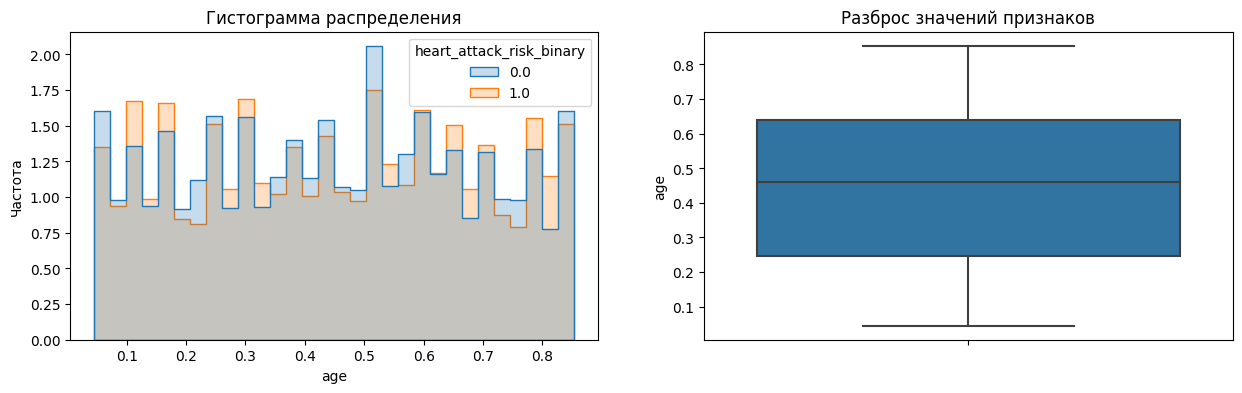

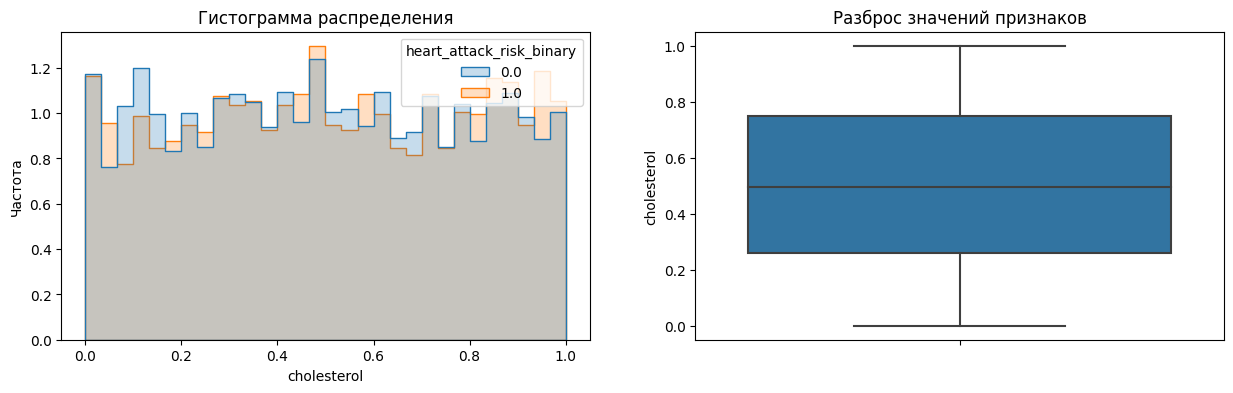

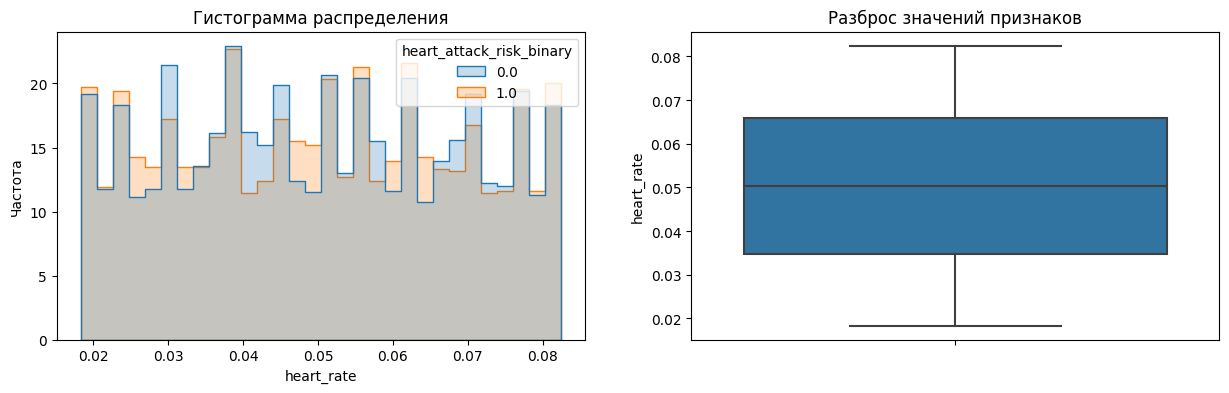

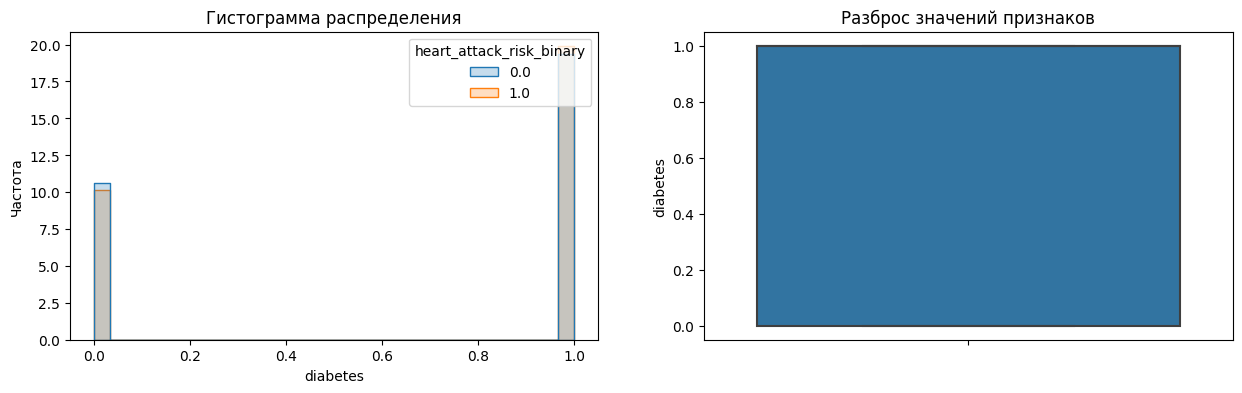

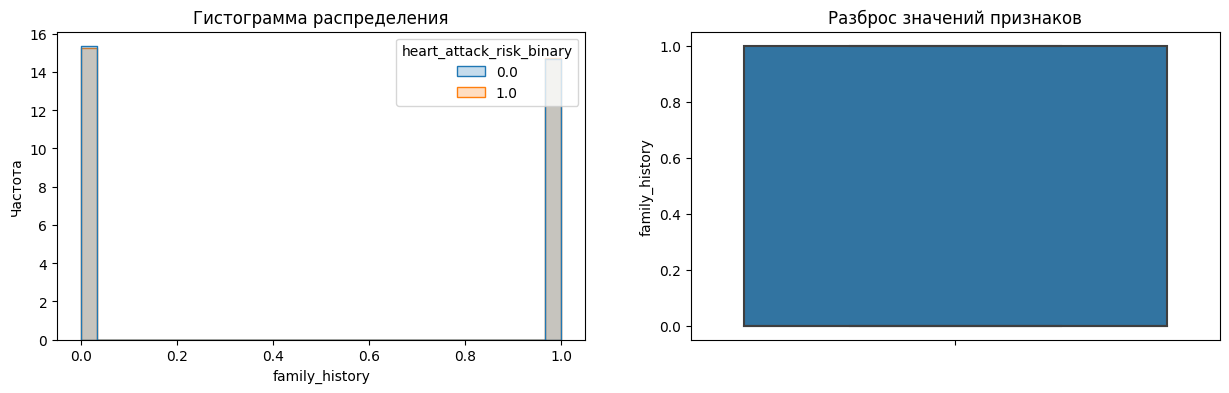

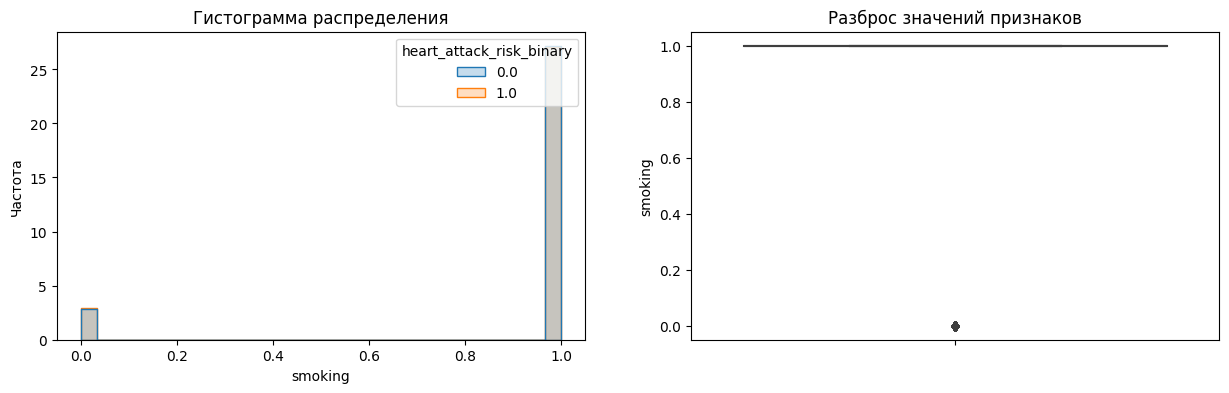

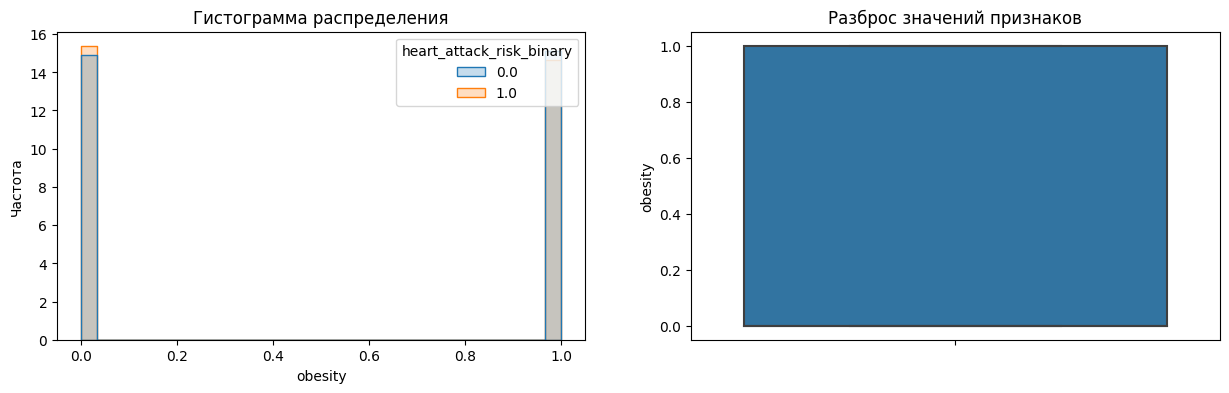

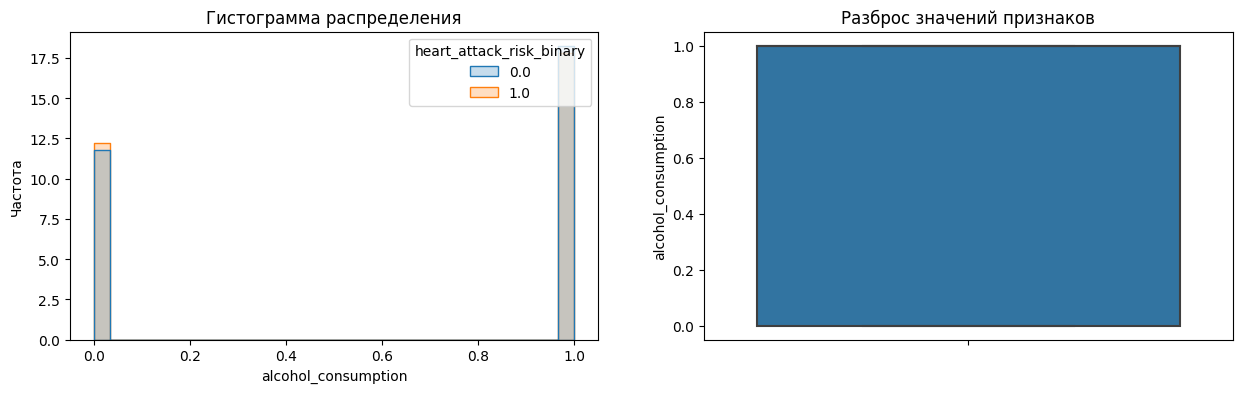

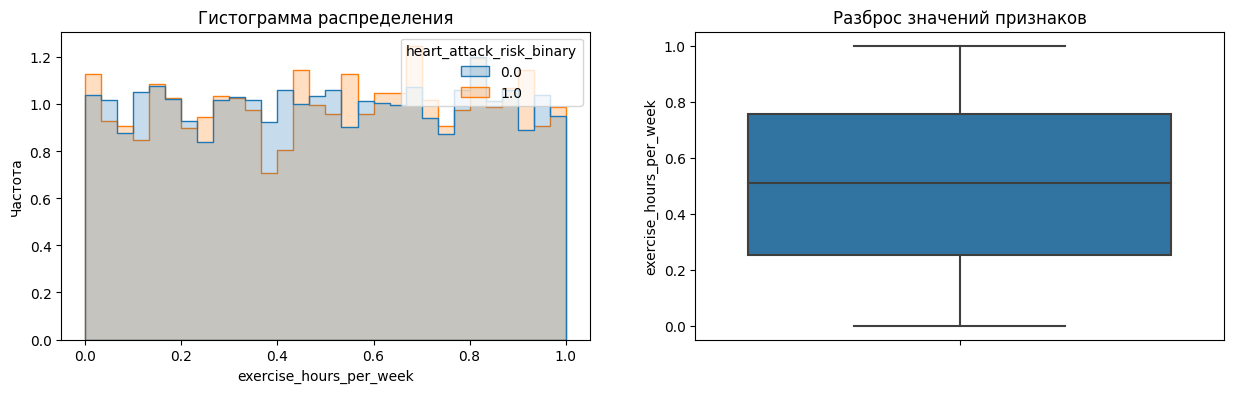

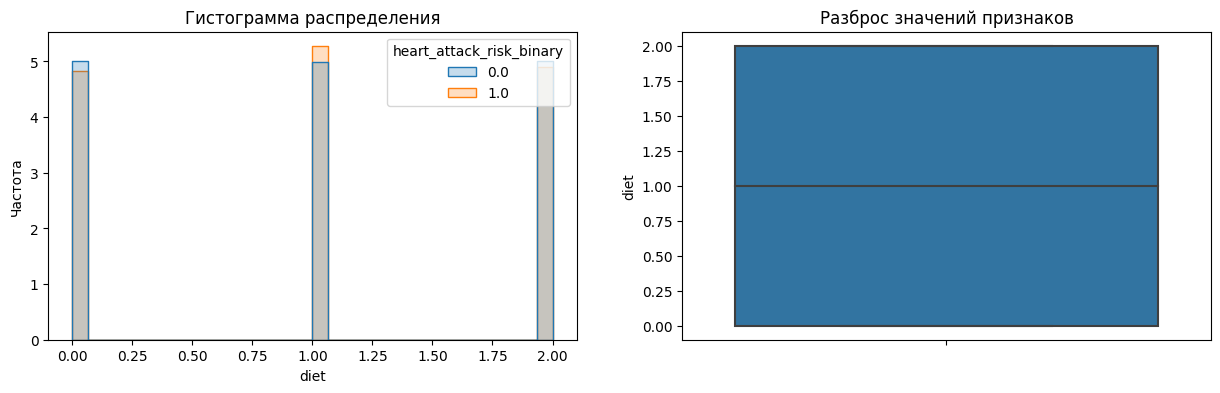

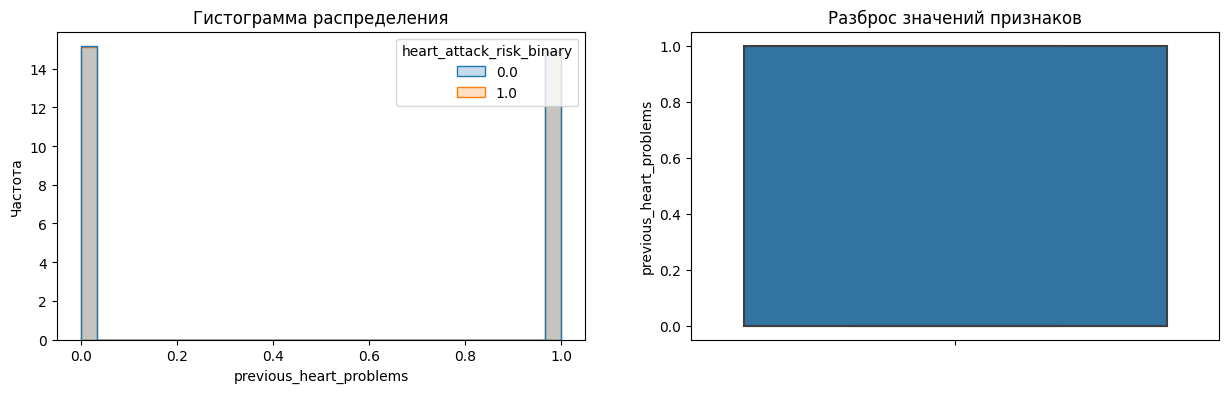

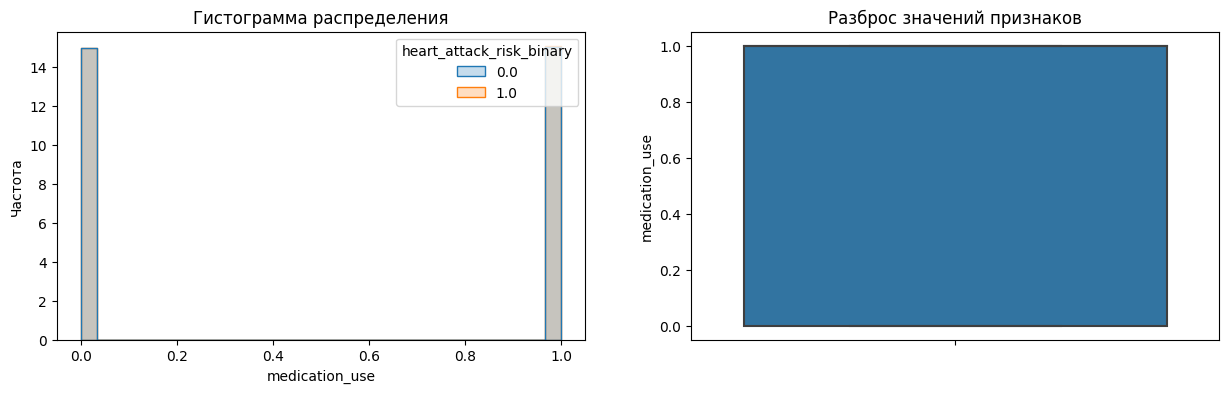

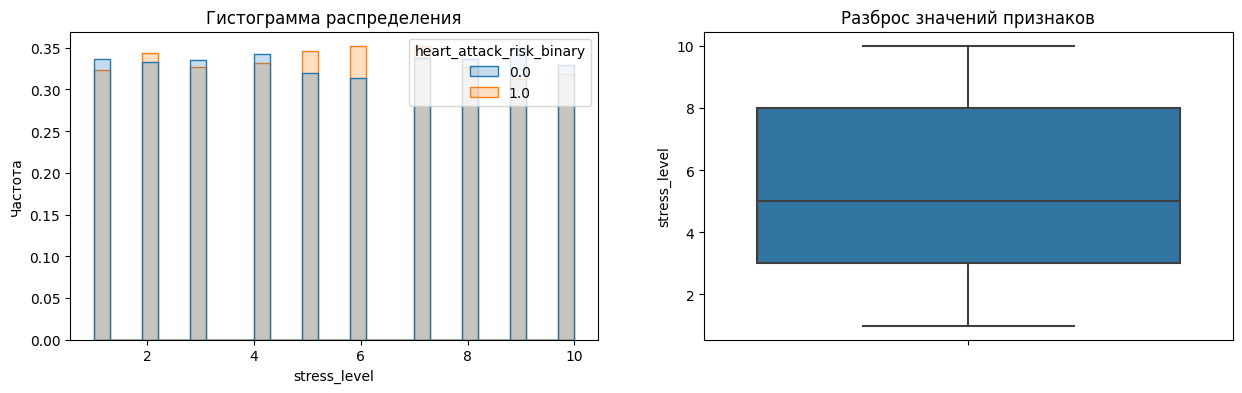

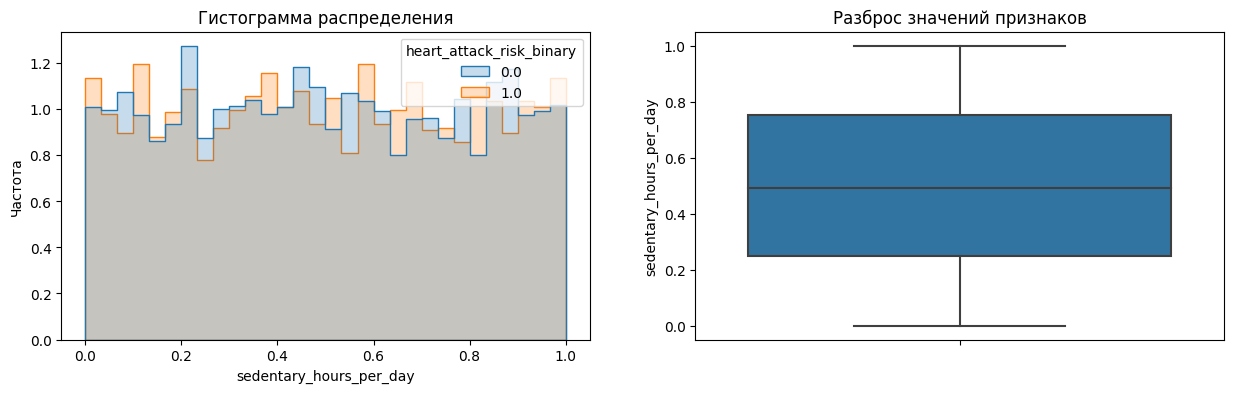

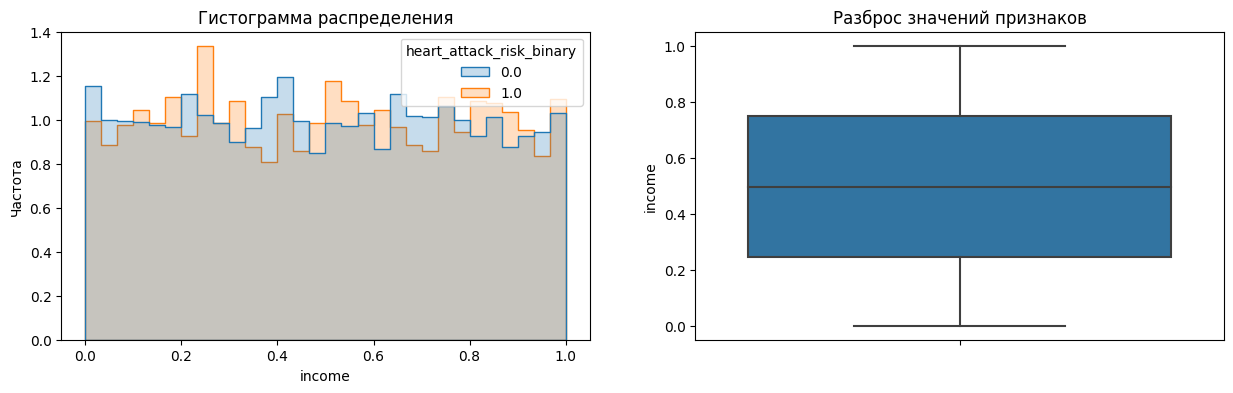

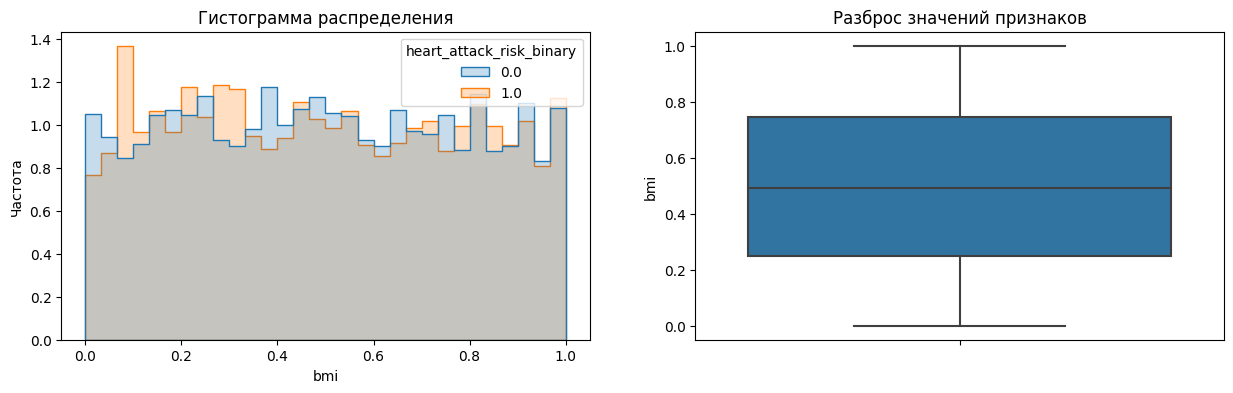

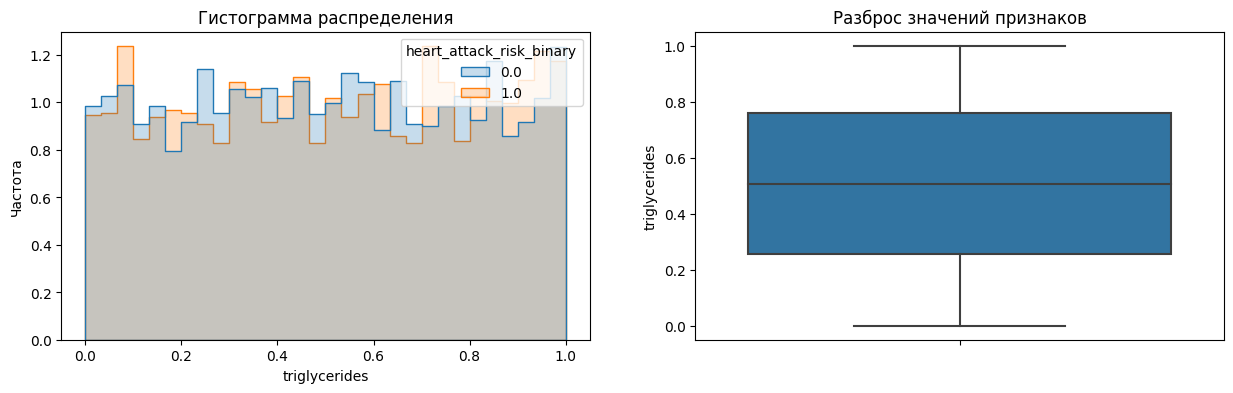

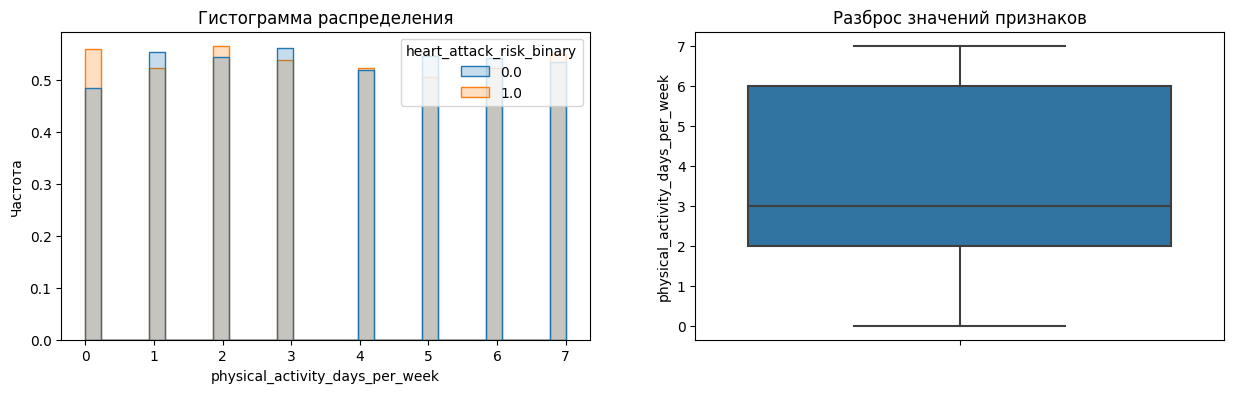

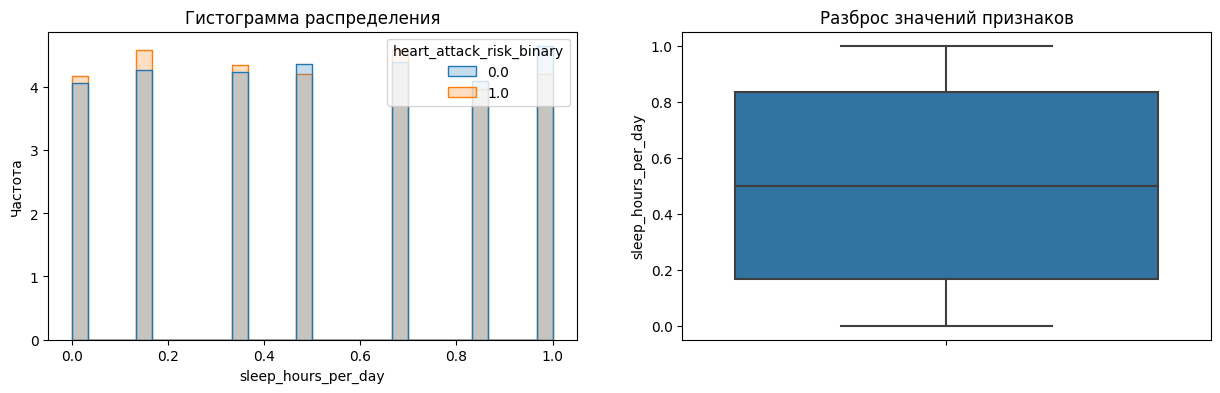

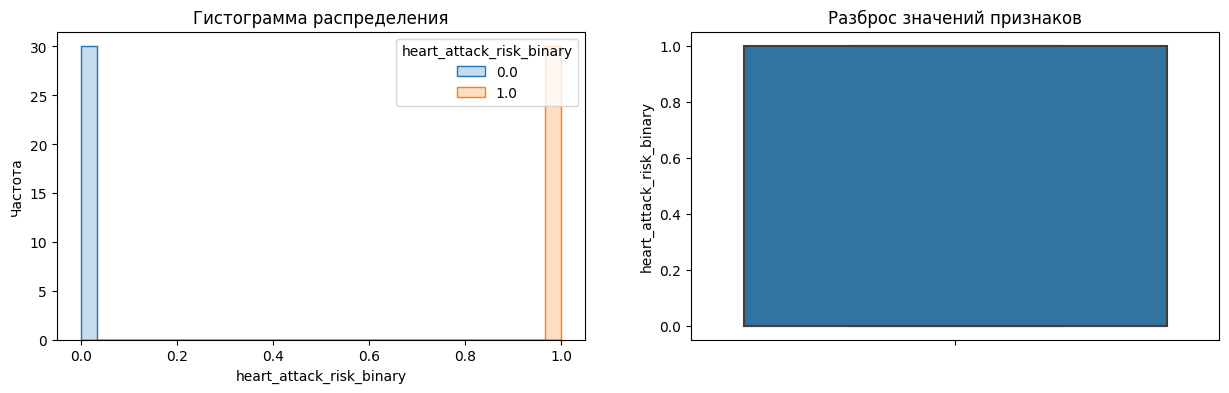

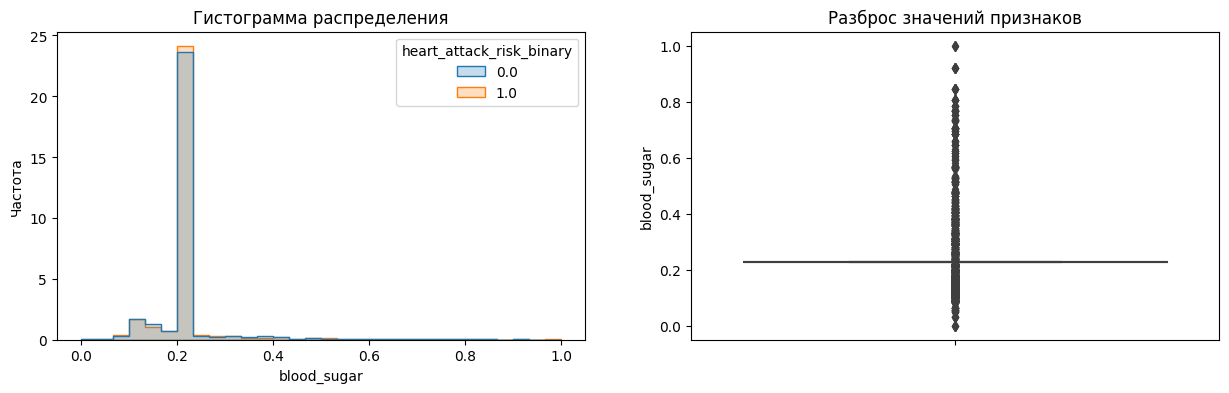

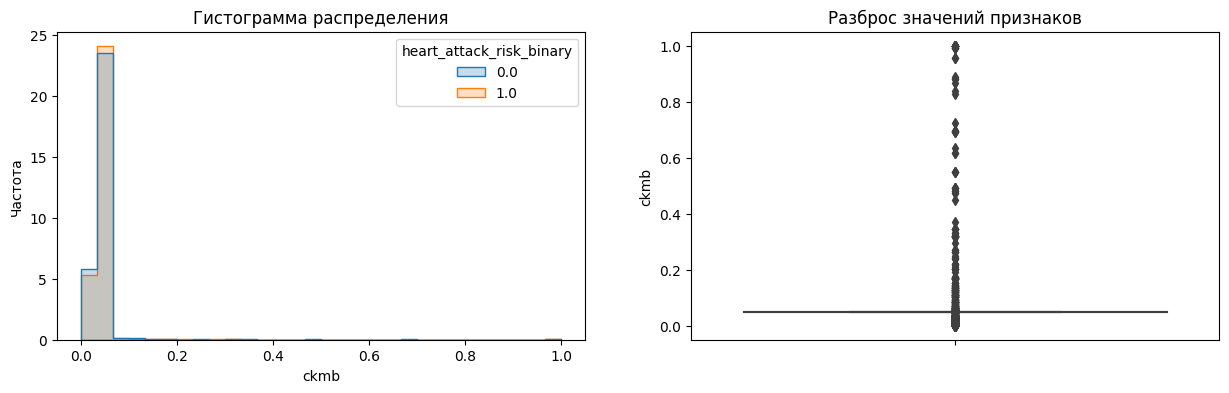

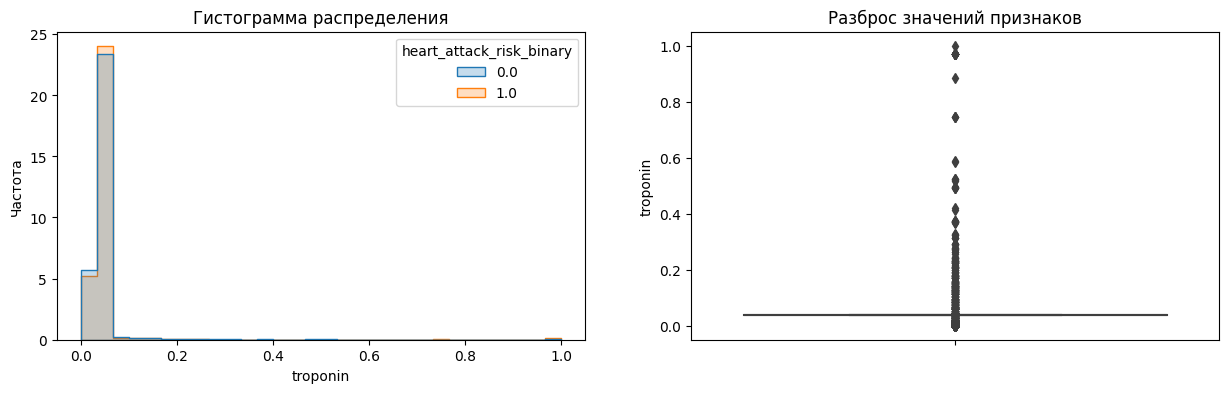

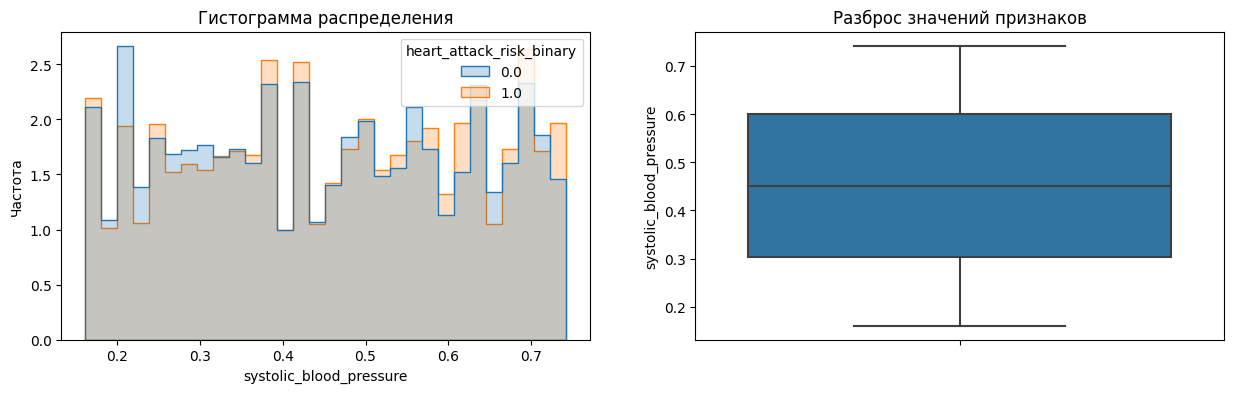

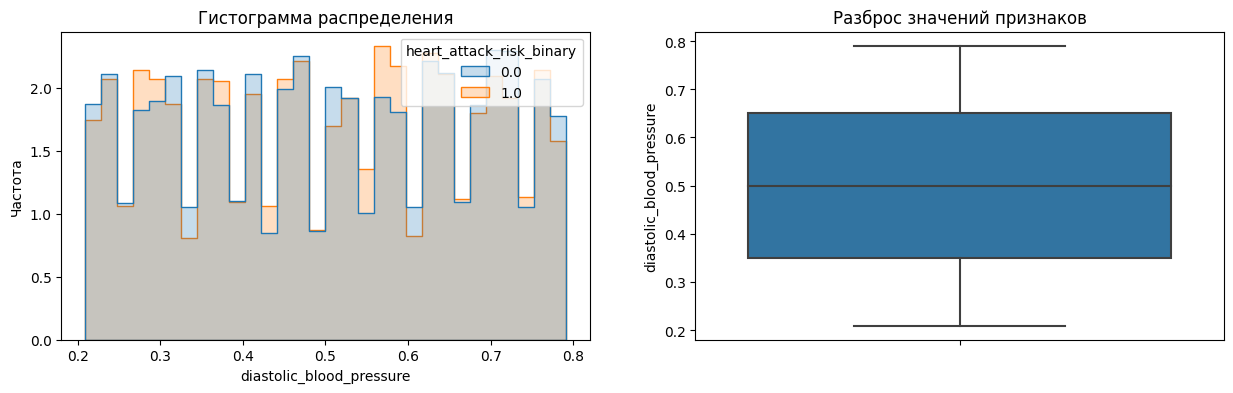

In [54]:
for column_name in ['age', 'cholesterol', 'heart_rate', 'diabetes', 'family_history',
       'smoking', 'obesity', 'alcohol_consumption', 'exercise_hours_per_week',
       'diet', 'previous_heart_problems', 'medication_use', 'stress_level',
       'sedentary_hours_per_day', 'income', 'bmi', 'triglycerides',
       'physical_activity_days_per_week', 'sleep_hours_per_day',
       'heart_attack_risk_binary', 'blood_sugar', 'ckmb', 'troponin', 
       'systolic_blood_pressure', 'diastolic_blood_pressure']:
    hist_boxaxes(df_train, column_name)

# Вывод
согласно данным гистограмм распределения:

Возврат - средние значения показателя характеризуются минимальным риском сердечного приступа

Холестерин - рост холестерина влечет увеличение риска

Диета - первого типа увеличивает риск, нулевого и второго уменьшает

Стресс уровень среднего значения - увеличивает риск

Алкоголь - не употребляющие алкоголь увеличивают риски приступа (возможно сопутствующие болезни ограничивают потребление алкоголя)

Остальные признаки показывают слабое влияние на риск сердечного приступа.

## Корреляционный анализ

In [55]:
#Уберем числовой id перед оценкой корреклиций
df_train = df_train.drop(['id'], axis=1)

interval columns not set, guessing: ['age', 'cholesterol', 'heart_rate', 'diabetes', 'family_history', 'smoking', 'obesity', 'alcohol_consumption', 'exercise_hours_per_week', 'diet', 'previous_heart_problems', 'medication_use', 'stress_level', 'sedentary_hours_per_day', 'income', 'bmi', 'triglycerides', 'physical_activity_days_per_week', 'sleep_hours_per_day', 'heart_attack_risk_binary', 'blood_sugar', 'ckmb', 'troponin', 'systolic_blood_pressure', 'diastolic_blood_pressure']


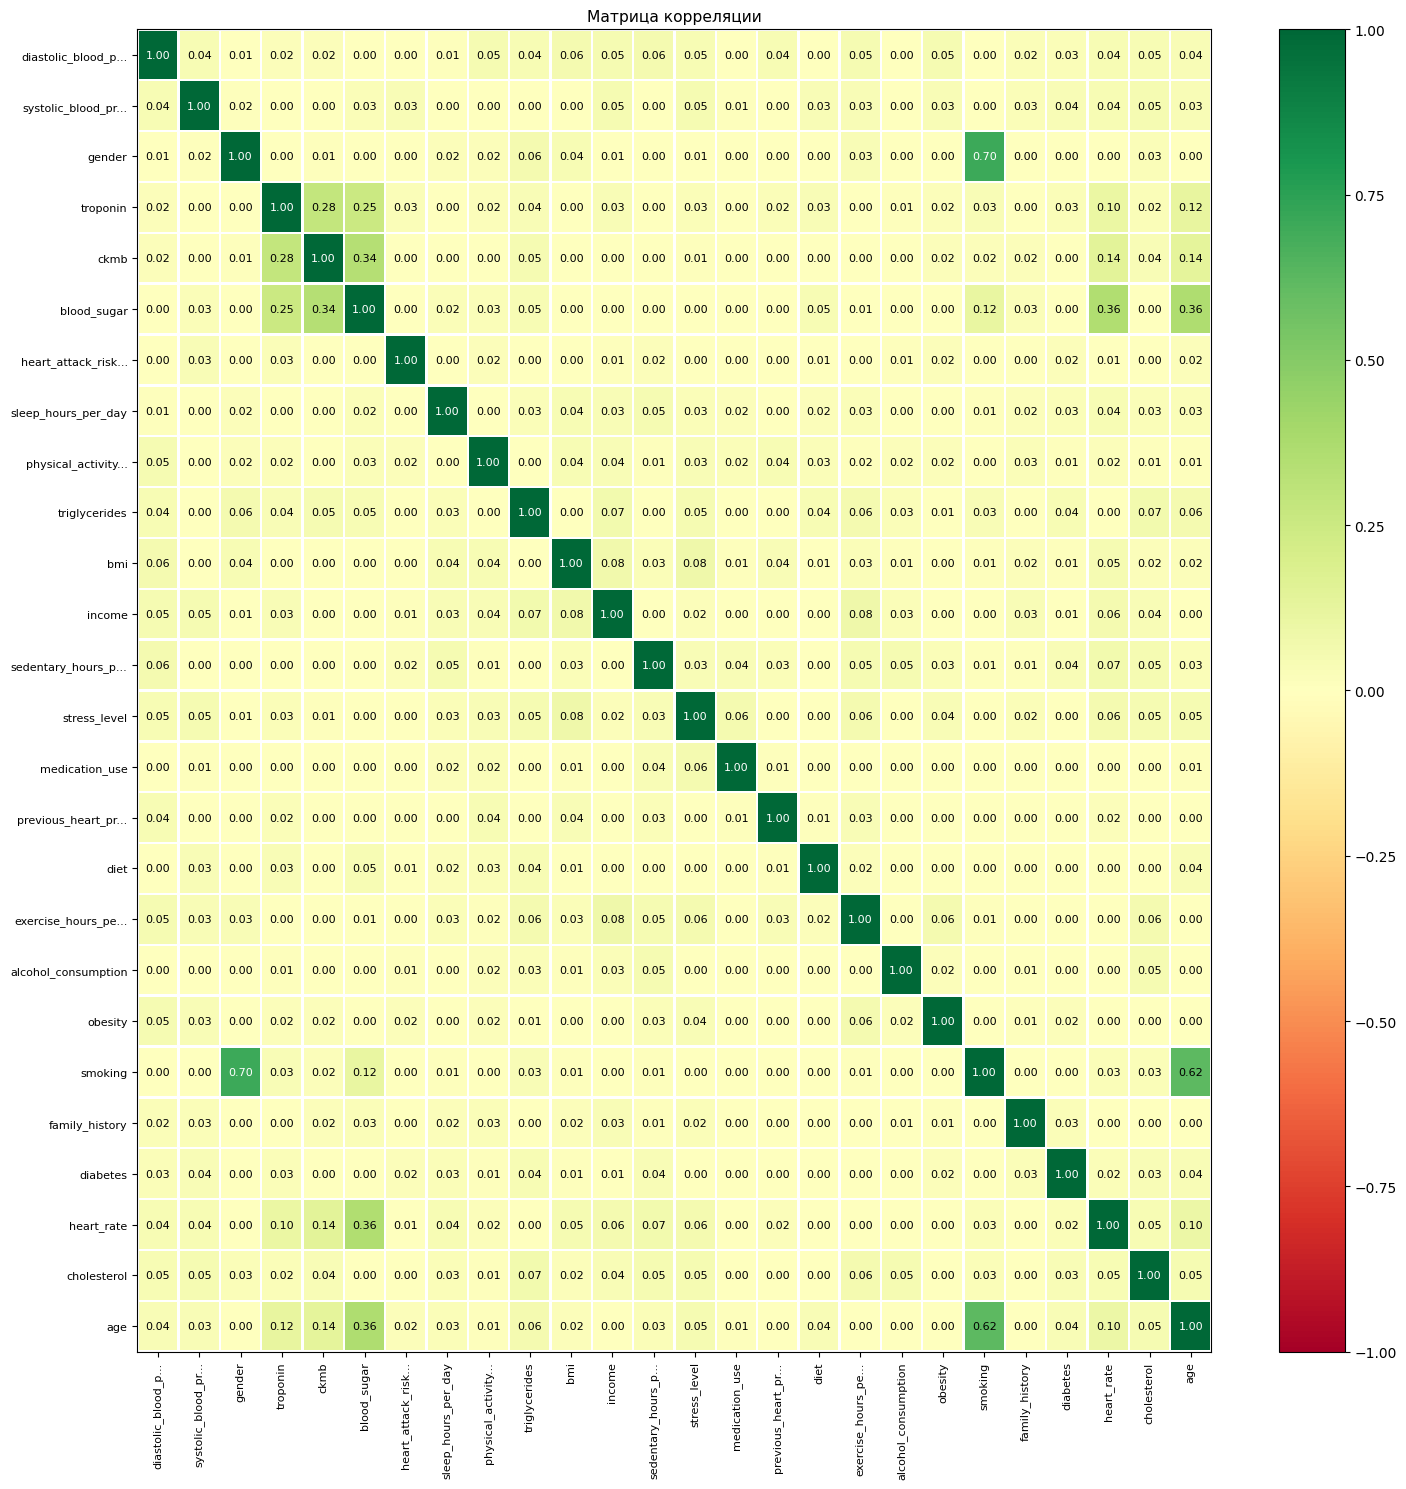

In [56]:
# вычисление коэффициентов корреляции phi для датафрейма df_train
phik_overview = df_train.phik_matrix()

# визуализация тепловой карты коэффициентов корреляции
plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    title="Матрица корреляции",
    fontsize_factor=0.8,
    figsize=(15, 15)
)

interval columns not set, guessing: ['age', 'cholesterol', 'heart_rate', 'diabetes', 'family_history', 'smoking', 'obesity', 'alcohol_consumption', 'exercise_hours_per_week', 'diet', 'previous_heart_problems', 'medication_use', 'stress_level', 'sedentary_hours_per_day', 'income', 'bmi', 'triglycerides', 'physical_activity_days_per_week', 'sleep_hours_per_day', 'blood_sugar', 'ckmb', 'troponin', 'systolic_blood_pressure', 'diastolic_blood_pressure', 'id']


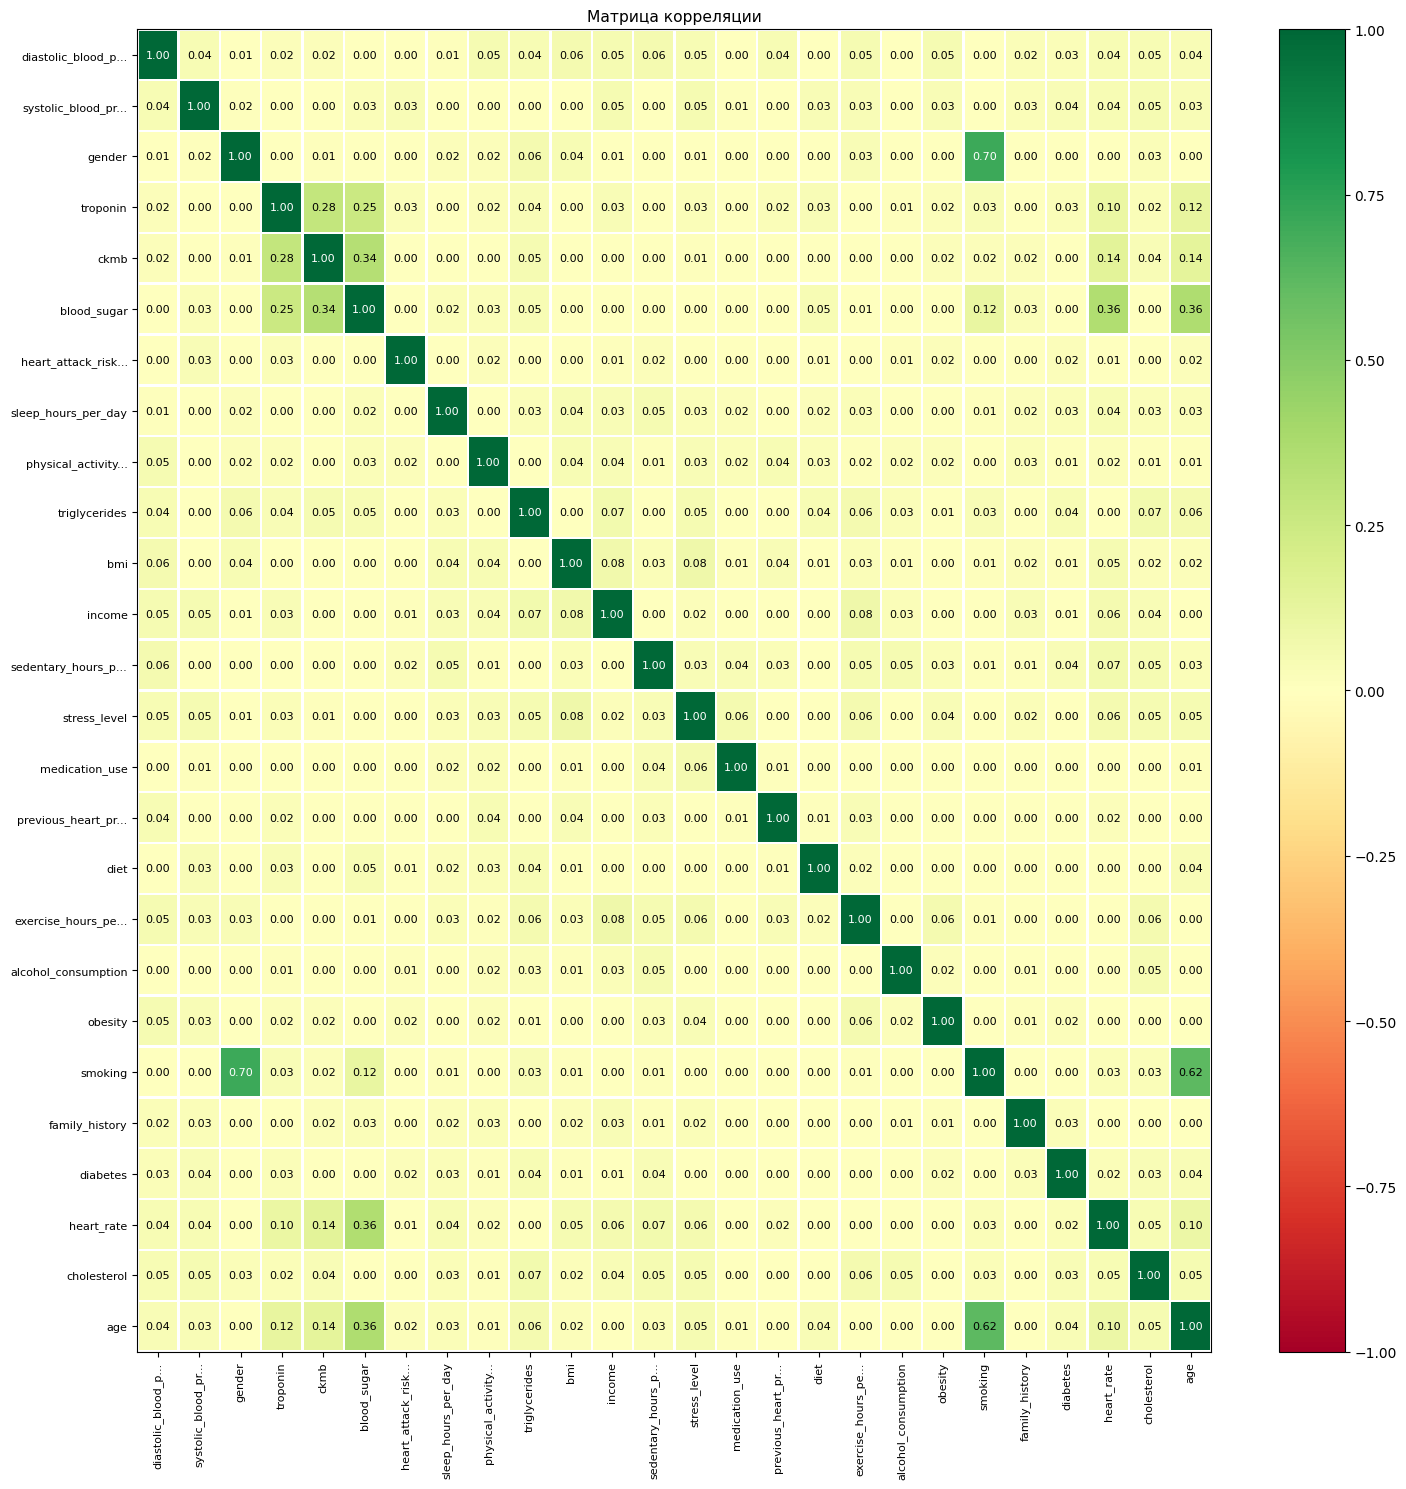

In [57]:
# вычисление коэффициентов корреляции phi для датафрейма df_test
phik_overview_test = df_test.phik_matrix()

# визуализация тепловой карты коэффициентов корреляции
plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    title="Матрица корреляции",
    fontsize_factor=0.8,
    figsize=(15, 15)
)

## Вывод:

- Мультикоррелинеарность отсудствует
- Нет утечки целевого признака (целевой признак слабо коррелирует с другими, максимум 0,03)
- Видна объектвная зависимость между курением, полом и возврастом

# Обучение и выбор модели

In [58]:
#Подготовка данных. Целевой признак - heart_attack_risk_binary

X_train, X_test, y_train, y_test = train_test_split(
    df_train.drop(['heart_attack_risk_binary'], axis=1),
    df_train['heart_attack_risk_binary'],
    test_size = TEST_SIZE, 
    random_state = RANDOM_STATE,
    stratify = df_train['heart_attack_risk_binary'])

X_train.columns

Index(['age', 'cholesterol', 'heart_rate', 'diabetes', 'family_history',
       'smoking', 'obesity', 'alcohol_consumption', 'exercise_hours_per_week',
       'diet', 'previous_heart_problems', 'medication_use', 'stress_level',
       'sedentary_hours_per_day', 'income', 'bmi', 'triglycerides',
       'physical_activity_days_per_week', 'sleep_hours_per_day', 'blood_sugar',
       'ckmb', 'troponin', 'gender', 'systolic_blood_pressure',
       'diastolic_blood_pressure'],
      dtype='object')

In [59]:
ohe_columns = ['gender']
ord_columns = ["family_history", "alcohol_consumption", "previous_heart_problems", "medication_use",'obesity' ] 
num_columns = ['age', 'cholesterol', 'heart_rate', 'diabetes', 
       'smoking', 'exercise_hours_per_week', 'diet', 'stress_level',
       'sedentary_hours_per_day', 'income', 'bmi', 'triglycerides',
       'physical_activity_days_per_week', 'sleep_hours_per_day', 'blood_sugar',
       'ckmb', 'troponin', 'systolic_blood_pressure',
       'diastolic_blood_pressure']

In [60]:
# SimpleImputer + OHE
ohe_pipe = Pipeline(
    [
        (
            'simpleImputer_ohe', 
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        ),
        (
            'ohe', 
            OneHotEncoder(drop='first')
        )
    ]
)

In [61]:
# SimpleImputer + ord + SimpleImputer
ord_pipe = Pipeline(
    [
        (
            'simple_imputer_ord_before',
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        ),
        (
            'ord',
            OrdinalEncoder(handle_unknown='use_encoded_value',
                          unknown_value=np.nan)
        ),
        (
            'simple_imputer_ord_after',
            SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        )
    ]
)

In [62]:
data_preprocessor = ColumnTransformer(
    [
        ('ohe', ohe_pipe, ohe_columns),
        ('ord', ord_pipe, ord_columns),
        ('num', StandardScaler(), num_columns)
    ], 
    remainder='passthrough'
)

In [63]:
# итоговый пайплайн: подготовка данных и модель
pipe_final = Pipeline(
    [
        ('preprocessor', data_preprocessor),
        ('models', DecisionTreeClassifier(random_state=RANDOM_STATE))
    ]
)

param_grid = [
    # словарь для модели DecisionTreeClassifier()
    {
        'models': [DecisionTreeClassifier(random_state=RANDOM_STATE)],
        'models__max_depth': range(5, 15),
        'models__max_features': range(5, 15),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough'],
        'preprocessor__ord': [ord_pipe, 'drop']
    },
    
    # словарь для модели LogisticRegression()
    {
        'models': [LogisticRegression(
            random_state=RANDOM_STATE, 
            solver='liblinear', 
            penalty='l1'
        )],
        'models__C': range(2, 7),
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough']  
    },
    #  RandomForest
    {
        'models': [RandomForestClassifier(random_state=42)],
        'models__n_estimators': randint(150, 300),
        'models__max_depth': [10, 15, 20],
        'models__min_samples_split': randint(2, 5),
        'models__min_samples_leaf': randint(1, 3),
        'models__class_weight': ['balanced', 'balanced_subsample']
    },
]

In [64]:
randomized_search = RandomizedSearchCV(
    pipe_final,
    param_grid,
    cv = 5,
    scoring = 'roc_auc',
    random_state = RANDOM_STATE,
    n_jobs = -1,
    verbose = 1

)

In [65]:
randomized_search.fit(X_train, y_train)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('ohe',
                                                                               Pipeline(steps=[('simpleImputer_ohe',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('ohe',
                                                                                                OneHotEncoder(drop='first'))]),
                                                                               ['gender']),
                                                                              ('ord',
                                                                               Pipeline(steps=[('simple_imputer_ord_before',
                                                                                                SimpleImputer(strategy='most_frequent')),...
                                         'models__max_depth': [10, 15, 20],
                                         'models__min_samples_leaf': <scipy.stats._distn_infrastructure.rv_frozen object at 0x0000020F0152E7C0>,
                                         'models__min_samples_split': <scipy.stats._distn_infrastructure.rv_frozen object at 0x0000020F01F18CA0>,
                                         'models__n_estimators': <scipy.stats._distn_infrastructure.rv_frozen object at 0x0000020F0152E370>}],
                   random_state=42, scoring='roc_auc', verbose=1)

In [66]:
print('Лучшая модель и её параметры:\n\n', randomized_search.best_estimator_)
print ('Метрика лучшей модели на тренировочной выборке:', round(randomized_search.best_score_, 2))

Лучшая модель и её параметры:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe',
                                                  Pipeline(steps=[('simpleImputer_ohe',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(drop='first'))]),
                                                  ['gender']),
                                                 ('ord',
                                                  Pipeline(steps=[('simple_imputer_ord_before',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ord',
                                                 

Лучшие модель оказалась RandomForestClassifier c метрикой 0.56, что чуть лучше чем случайность. Данный результат обусловлен низкой кореляцией всех признаков.
Оценим важность факторов

In [67]:
df_train.columns

Index(['age', 'cholesterol', 'heart_rate', 'diabetes', 'family_history',
       'smoking', 'obesity', 'alcohol_consumption', 'exercise_hours_per_week',
       'diet', 'previous_heart_problems', 'medication_use', 'stress_level',
       'sedentary_hours_per_day', 'income', 'bmi', 'triglycerides',
       'physical_activity_days_per_week', 'sleep_hours_per_day',
       'heart_attack_risk_binary', 'blood_sugar', 'ckmb', 'troponin', 'gender',
       'systolic_blood_pressure', 'diastolic_blood_pressure'],
      dtype='object')

In [75]:
best_model = randomized_search.best_estimator_

# Получаем имена признаков
 
all_features = ['age', 'cholesterol', 'heart_rate', 'diabetes', 'family_history',
       'smoking', 'obesity', 'alcohol_consumption', 'exercise_hours_per_week',
       'diet', 'previous_heart_problems', 'medication_use', 'stress_level',
       'sedentary_hours_per_day', 'income', 'bmi', 'triglycerides',
       'physical_activity_days_per_week', 'sleep_hours_per_day',
     'blood_sugar', 'ckmb', 'troponin', 'gender',
       'systolic_blood_pressure', 'diastolic_blood_pressure']
importances = best_model.named_steps['models'].feature_importances_[:len(all_features)]
    
feat_imp = pd.DataFrame({'feature': all_features, 'importance': importances})
feat_imp = feat_imp.sort_values('importance', ascending=False)
print("Топ-15 важных признаков (упрощенно):")
print(feat_imp.head(15))

Топ-15 важных признаков (упрощенно):
                            feature  importance
16                    triglycerides    0.082042
15                              bmi    0.080642
14                           income    0.078821
11                   medication_use    0.078143
17  physical_activity_days_per_week    0.077389
7               alcohol_consumption    0.074307
23          systolic_blood_pressure    0.068317
6                           obesity    0.067624
8           exercise_hours_per_week    0.066143
24         diastolic_blood_pressure    0.064139
13          sedentary_hours_per_day    0.040836
18              sleep_hours_per_day    0.037009
19                      blood_sugar    0.033637
21                         troponin    0.018468
20                             ckmb    0.018091


## Вывод
Подготовлен пайплайн поиска оптимальной модели:
One-Hot Encoding для категориальных признаков
Ordinal Encoding для бинарных признаков
Масштабирование числовых признаков
Результат: Построена модель с оптимальными параметрами

Лучшие модель оказалась RandomForestClassifier (249 деревьев, глубиной 20) c метрикой ROC-AUC = 0.56, что чуть лучше чем случайность. Данный результат обусловлен низкой кореляцией всех признаков. 

Оценена важность факторов:

    triglycerides (0.082) - уровень триглицеридов
    bmi (0.0881) - Индекс массы тела
    income (0.079) - Доход
    medication_use CK-MB (0.078) - прием припаратов
    physical_activity_days_per_week (0.076) - Физическая активность 

Исходя из логики указнные признаки уместны.

Вывод: Модель в целом не пригодня для клинического применения



## Предсказание на тестовой выборке

In [69]:
# Тесовый датафрейм с преобразованием имен столбцов
X_test = df_test
# Cохраняем id для последующего объедениения с предсказаниями
X_test_id = X_test['id']
# Оставляем только нужные столбцы
X_test = X_test[[
    'bmi', 'age', 'triglycerides',
    'diastolic_blood_pressure', 'income',
    'heart_rate', 'exercise_hours_per_week', 'sedentary_hours_per_day',
    'cholesterol', 'systolic_blood_pressure',  'physical_activity_days_per_week',
    'stress_level', 'sleep_hours_per_day','medication_use', 'ckmb', 'previous_heart_problems', 'alcohol_consumption', 
    'diet', 'blood_sugar', 'troponin', 'gender', 'diabetes', 'smoking', 'family_history', 'obesity'
]]

In [70]:
# Получение препроцессора из пайплайна
preprocessor = best_model.named_steps[
        'preprocessor']
# Подготовка данных X_test_preproc  
X_test_preproc = preprocessor.transform(
        X_test)

In [71]:
# Получение модели из пайплайна
best_estimator = randomized_search.best_estimator_[-1]
# Предсказания 
y_prediction = best_estimator.predict(
    X_test_preproc)

In [72]:
y_prediction = pd.Series(y_prediction)
predictions = pd.concat([
    X_test_id,
    y_prediction
],
    axis=1
)
predictions.columns = ['id','prediction']

In [73]:
# Сохранение предсказаний в CSV в папку проекта
try:
    predictions.to_csv('predictions.csv', 
                       index=False,
                       encoding='utf-8',
                       sep=',')
    print("Файл успешно сохранен")
except Exception as e:
    print(f"Ошибка при сохранении файла: {str(e)}")

Файл успешно сохранен


## Сохраним модель

In [74]:
joblib.dump(randomized_search.best_estimator_[-1], 'best_model.pkl')
joblib.dump(preprocessor, 'preprocessor.pkl')

['preprocessor.pkl']

# Общий вывод

Проведен первичный анализ данных:

    - Изучены типы и колонки датасетов
    - Изучены пропуски
    - Определен целевой признак - heart_attack_risk_binary
Выполнена предобработка данных:

    - Приведены наименования колонок к snake_case, заменены пробелы
    - Удалена колонка неизвестных значений Unnamed: 0
    - Проанализрованы пропуски - удалены строки тренировочных и тестовой выборок
    - Проанализированы дубликаты
    
Выполнен исследовательский анализ данных:

    Согласно построенным графикам распределения:
    Возраст - средние значения показателя характеризуются минимальным риском сердечного приступа
    Холестерин - рост холестерина влечет увеличение риска
    Диета - первого типа увеличивает риск, нулевого и второго уменьшает
    Стресс уровень среднего значения - увеличивает риск
    Алкоголь - не употребляющие алкоголь увеличивают риски приступа (возможно сопутствующие болезни ограничивают потребление алкоголя)
    Остальные признаки показывают слабое влияние на риск сердечного приступа.

Корреляционный анализ показал:

    - Мультикоррелинеарность отсудствует
    - Нет утечки целевого признака (целевой признак слабо коррелирует с другими, максимум 0,03)
    - Видна объектвная зависимость между курением, полом и возврастом

Далее выполнено обучение и проверка моделей

Выбор метрики обсуловлен стремлением свести к минимуму ложно положительную ошибку, т.е, важность пложительных и отрицательных предсказаний одинаковая, также имеются выбросы данных. С учетом изложенного выбрана метрика ROC-AUC.

    - Подготовлен пайплайн поиска оптимальной модели: One-Hot Encoding для категориальных признаков Ordinal Encoding для бинарных признаков Масштабирование числовых признаков
    - Построена модель с оптимальными параметрами. Лучшие модель оказалась RandomForestClassifier (249 деревьев, глубиной 20) c метрикой ROC-AUC = 0.56, что чуть лучше чем случайность. Данный результат обусловлен низкой кореляцией всех признаков.

Оценена важность факторов:

    triglycerides (0.082) - уровень триглицеридов
    bmi (0.0881) - Индекс массы тела
    income (0.079) - Доход
    medication_use CK-MB (0.078) - прием припаратов
    physical_activity_days_per_week (0.076) - Физическая активность 
Исходя из логики указнные признаки уместны.

Вывод: Модель в целом не пригодня для клинического применения

Далее произведена выгрузка предсказаний модели в в CSV в файл predictions.csv

Сохранена модель для использования в стороннем приложении